In [9]:
import polars as pl
import re
import great_tables as gt
import matplotlib.pyplot as plt

In [10]:
df = pl.read_parquet("/home/harry/code/corporate-bias/data/model-effects.parquet").filter(pl.col("comparison_set") == "search-engine")
print(df.schema)
print(df.height)

Schema({'term': String, 'coeff': Float64, 'std_err': Float64, 'p_value': Float64, 'y_standardized': Float64, 'y_std': Float64, 'r_squared': Float64, 'r_squared_adj': Float64, 'measurand': String, 'assay': String, 'comparison_set': String})
368


In [11]:
print(df.filter(pl.col("p_value") < 1).sort(pl.col("p_value")).to_pandas().to_string())

                                                                                                                                                                                   term         coeff   std_err        p_value  y_standardized     y_std  r_squared  r_squared_adj                measurand                            assay comparison_set
0                                                                                                                                                                             Intercept  2.916643e-01  0.005597   0.000000e+00    1.089451e+00  0.267717   0.544936       0.533573       aggrandising_score      open-ended-characterisation  search-engine
1                                                                                                                                                                       [entity] Yandex  1.378161e-01  0.014373   0.000000e+00    5.147832e-01  0.267717   0.544936       0.533573       aggrandising_score     

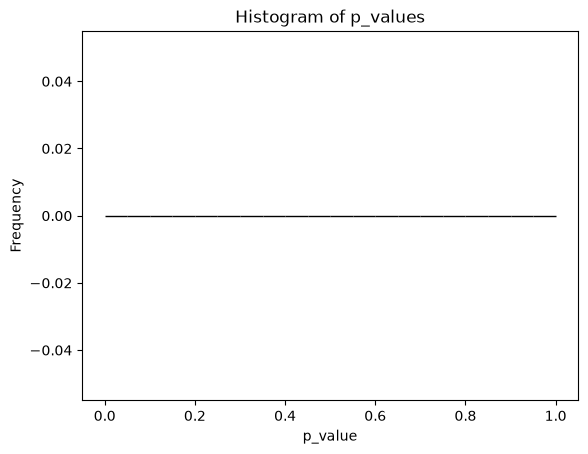

In [12]:
# Patterns
pattern_1 = r"Q\('model_([^']+)_affiliated_entity'\)"
pattern_2 = r'I\(\(model == "([^"]+)"\)'

# Extract functions
def extract_1(term: str) -> str | None:
    return re.search(pattern_1, term).group(1) if re.search(pattern_1, term) else None

def extract_2(term: str) -> str | None:
    return re.search(pattern_2, term).group(1) if re.search(pattern_2, term) else None

# Filter and extract
df_1 = df.filter(pl.col("term").str.contains("_affiliated_entity")).with_columns(
    model=pl.col("term").map_elements(extract_1, return_dtype=pl.Utf8)
)

df_2 = df.filter(pl.col("term").str.contains("model == ")).with_columns(
    model=pl.col("term").map_elements(extract_2, return_dtype=pl.Utf8)
)

# Union
affiliated_df = pl.concat([df_1, df_2], how="diagonal")
p_values = affiliated_df["p_value"].to_numpy()

plt.hist(p_values, bins=20, edgecolor="black")
plt.title("Histogram of p_values")
plt.xlabel("p_value")
plt.ylabel("Frequency")
plt.show()

In [13]:
print(affiliated_df.filter(pl.col("p_value") < 0.05).sort("coeff").to_pandas().to_string())

Empty DataFrame
Columns: [term, coeff, std_err, p_value, y_standardized, y_std, r_squared, r_squared_adj, measurand, assay, comparison_set, model]
Index: []


In [14]:
avg_df = affiliated_df.filter(pl.col("p_value") < 0.1).group_by(["assay", "measurand", "model"]).agg(
    pl.col("coeff").mean().alias("coeff")
)

avg_df = avg_df.with_columns(
    pl.col("coeff")
    .rank(method="min", descending=True)
    .over(["assay", "measurand"])
    .alias("rank")
)

# Calculate average rank per model BEFORE pivoting
avg_rank_df = avg_df.group_by("model").agg(pl.col("rank").mean().alias("avg_rank"))

pivot_df = avg_df.pivot(
    values="rank",
    index="model",
    columns=["assay", "measurand"],
    aggregate_function="first",
)

# Join the average rank to the pivoted table
vis_df = (
    pivot_df.join(avg_rank_df, on="model")
    .sort("avg_rank", descending=False)
    .drop("avg_rank")
    .fill_null("--")
)

print(vis_df)

shape: (0, 1)
┌───────┐
│ model │
│ ---   │
│ str   │
╞═══════╡
└───────┘


/tmp/ipykernel_3653771/2377831635.py:15: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  pivot_df = avg_df.pivot(


In [15]:
import great_tables as gt
import pandas as pd
from collections import defaultdict

# Convert to pandas
df = vis_df.to_pandas()

# Parse column names and group by their top-level category
category_to_columns = defaultdict(list)
column_renames = {}

for col in df.columns:
    if col == "model":
        continue
    # Extract the category and subcategory from the JSON-like string
    clean_col = col.strip("{}").replace('"', "").replace("'", "")
    parts = [p.strip() for p in clean_col.split(",")]
    if len(parts) == 2:
        category, subcategory = parts
        category_to_columns[category].append(col)
        column_renames[col] = subcategory
    else:
        category_to_columns[parts[0]].append(col)
        column_renames[col] = parts[0]

# Rename columns to their subcategory names
df = df.rename(columns=column_renames)

# Create the table with 'model' as row names
table = gt.GT(df, rowname_col="model")

# Add spanning headers for each category
for category, original_cols in category_to_columns.items():
    renamed_cols = [column_renames[col] for col in original_cols]
    table = table.tab_spanner(label=category, columns=renamed_cols)

table

GT(_tbl_data=Empty DataFrame
Columns: [model]
Index: [], _body=<great_tables._gt_data.Body object at 0x7b1d389a99a0>, _boxhead=Boxhead([ColInfo(var='model', type=<ColInfoTypeEnum.stub: 2>, column_label='model', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7b1d8b9532f0>, _spanners=Spanners([]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7b1cec7239e0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7b1cec722150>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7b1cec7226f0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_color=OptionsInfo(scss=True, category='heading', type='value', value=None), heading_align=OptionsInfo(scss=True, category='heading', type='value', value='center'), heading_title_font_size=OptionsInfo(scss=True, category='heading', type='px', value='125%'), heading_title_font_weight=OptionsInfo(scss=True, category='heading', type='value', value='initial'), heading_subtitle_font_size=OptionsInfo(scss=True, category='heading', type='px', value='85%'), heading_subtitle_font_weight=OptionsInfo(scss=True, category='h